# Análisis Exploratorio de Datos (EDA)
## Dataset: House Price Prediction - Seattle

**Fuente:** Kaggle - [House Price Prediction - Seattle](https://www.kaggle.com/datasets/samuelcortinhas/house-price-prediction-seattle)

**Descripción:** El dataset contiene información real de ventas de casas en el área de Seattle, Washington (EE. UU.), incluyendo el precio de venta y características físicas de cada propiedad (tamaño, número de habitaciones, año de construcción, ubicación, entre otras).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


In [2]:
data = pd.read_csv("modified_data.csv")
data.head()


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


# Descripción general del dataset

In [3]:
# Cantidad de filas y columnas
data.shape


(4600, 18)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   object 
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   object 
 15  city            4600 non-null   object 
 16  statezip        4600 non-null   object 
 17  price_per_sqft  4600 non-null   f

Granularidad: cada fila representa la venta de una vivienda individual en el área de Seattle.

In [5]:
# Revisión de valores nulos
data.isna().sum()


date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
street            0
city              0
statezip          0
price_per_sqft    0
dtype: int64

In [6]:
# Revisión de posibles inconsistencias: precios en cero
print("Registros con price == 0:", (data['price'] == 0).sum())
print("Registros con bedrooms == 0:", (data['bedrooms'] == 0).sum())

# Se eliminan registros con precio 0, ya que corresponden a datos inválidos (no ventas reales)
data = data[data['price'] > 0].copy()
data.shape


Registros con price == 0: 49
Registros con bedrooms == 0: 2


(4551, 18)

In [7]:
data['date'] = pd.to_datetime(data['date'])

columns_date = ['date']
columns_categorical = ['waterfront', 'view', 'condition', 'floors', 'city']
columns_numerical = [col for col in data.columns
                      if col not in columns_date + columns_categorical
                      and col not in ['street', 'statezip']]

for col in columns_categorical:
    data[col] = data[col].astype('category')

print("Fecha:", columns_date)
print("Categóricas:", columns_categorical)
print("Numéricas:", columns_numerical)


Fecha: ['date']
Categóricas: ['waterfront', 'view', 'condition', 'floors', 'city']
Numéricas: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'price_per_sqft']


In [8]:
data.describe()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4551,4.551000e+03,4551.000000,4551.000000,4551.000000,4.551000e+03,4551.000000,4551.000000,4551.000000,4551.000000,4551.000000
mean,2014-06-07 03:59:12.537903872,5.579059e+05,3.394639,2.155021,2132.372226,1.483528e+04,1822.221710,310.150516,1970.795649,808.564052,268.738862
min,2014-05-02 00:00:00,7.800000e+03,0.000000,0.000000,370.000000,6.380000e+02,370.000000,0.000000,1900.000000,0.000000,10.000000
25%,2014-05-21 00:00:00,3.262643e+05,3.000000,1.750000,1460.000000,5.000000e+03,1190.000000,0.000000,1951.000000,0.000000,182.890000
50%,2014-06-09 00:00:00,4.650000e+05,3.000000,2.250000,1970.000000,7.680000e+03,1590.000000,0.000000,1976.000000,0.000000,245.420000
75%,2014-06-24 00:00:00,6.575000e+05,4.000000,2.500000,2610.000000,1.097800e+04,2300.000000,600.000000,1997.000000,1999.000000,315.735000
max,2014-07-10 00:00:00,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000
std,NaN,5.639299e+05,0.904595,0.776351,955.949708,3.596408e+04,854.452888,461.987629,29.760073,979.421487,358.351196


# Análisis univariante\n\n## Categórico


ANÁLISIS DE: WATERFRONT

Cantidad de categorías: 2


,Categoría,Conteo,Porcentaje (%)
0,0,4521,99.34
1,1,30,0.66


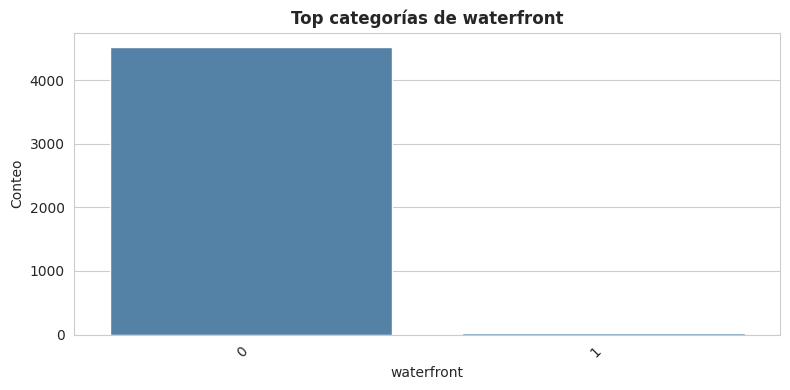


ANÁLISIS DE: VIEW

Cantidad de categorías: 5


,Categoría,Conteo,Porcentaje (%)
0,0,4103,90.16
1,2,201,4.42
2,3,115,2.53
3,1,69,1.52
4,4,63,1.38


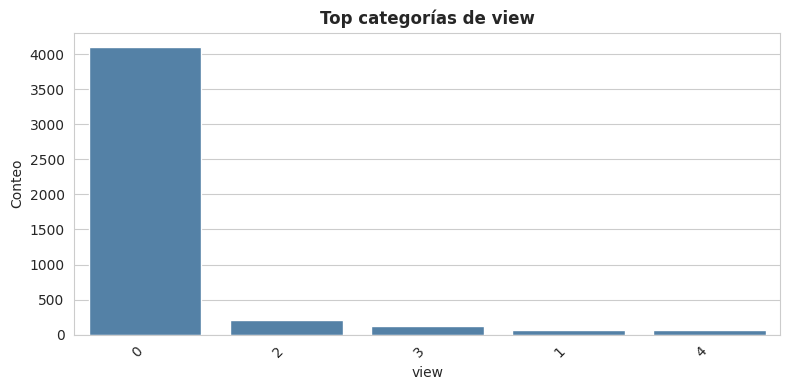


ANÁLISIS DE: CONDITION

Cantidad de categorías: 5


,Categoría,Conteo,Porcentaje (%)
0,3,2851,62.65
1,4,1238,27.20
2,5,425,9.34
3,2,31,0.68
4,1,6,0.13


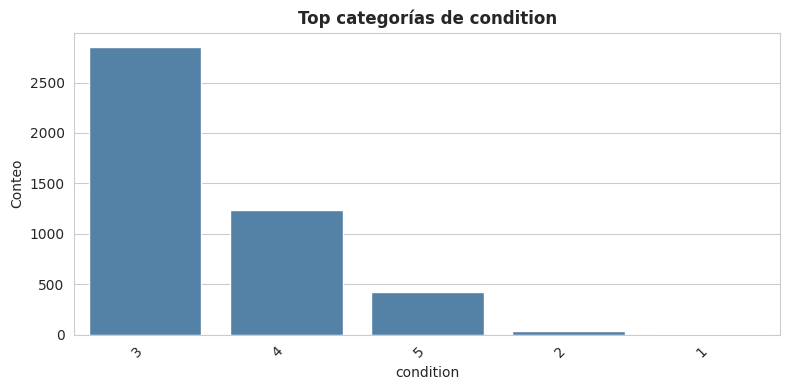


ANÁLISIS DE: FLOORS

Cantidad de categorías: 6


,Categoría,Conteo,Porcentaje (%)
0,1.0,2151,47.26
1,2.0,1791,39.35
2,1.5,439,9.65
3,3.0,127,2.79
4,2.5,41,0.90
5,3.5,2,0.04


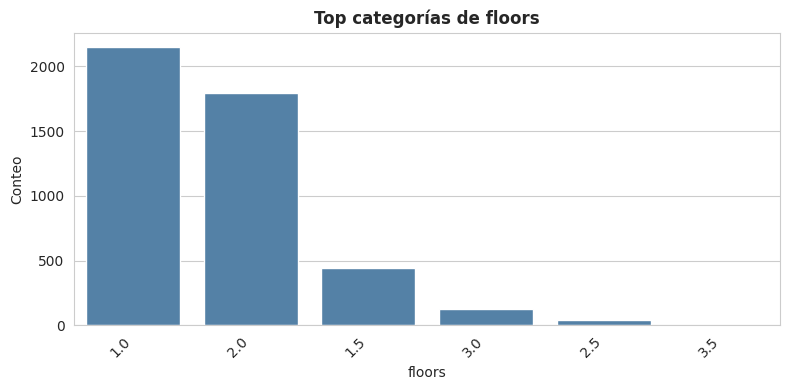


ANÁLISIS DE: CITY

Cantidad de categorías: 44


,Categoría,Conteo,Porcentaje (%)
0,Seattle,1561,34.30
1,Renton,291,6.39
2,Bellevue,281,6.17
3,Redmond,235,5.16
4,Kirkland,187,4.11
5,Issaquah,186,4.09
6,Kent,184,4.04
7,Auburn,175,3.85
8,Sammamish,171,3.76
9,Federal Way,145,3.19


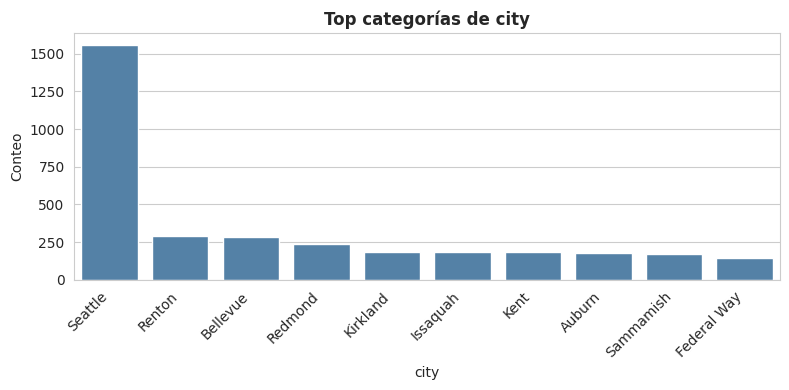

In [9]:
for col in columns_categorical:
    print(f"\n{'='*70}")
    print(f"ANÁLISIS DE: {col.upper()}")
    print(f"{'='*70}")

    num_categories = data[col].nunique()
    print(f"\nCantidad de categorías: {num_categories}")

    value_counts = data[col].value_counts()
    percentage = (value_counts / len(data) * 100).round(2)

    table = pd.DataFrame({
        'Categoría': value_counts.index,
        'Conteo': value_counts.values,
        'Porcentaje (%)': percentage.values
    })

    # Si hay muchas categorías (ej. city), mostramos solo el top 10
    display(table.head(10))

    top_n = value_counts.head(10)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=top_n.index.astype(str), y=top_n.values, color='steelblue')
    plt.title(f'Top categorías de {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Conteo', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## Numérico


ANÁLISIS DE: PRICE


,count,mean,std,min,25%,50%,75%,max
price,4551.0,557905.899134,563929.871277,7800.0,326264.285,465000.0,657500.0,26590000.0


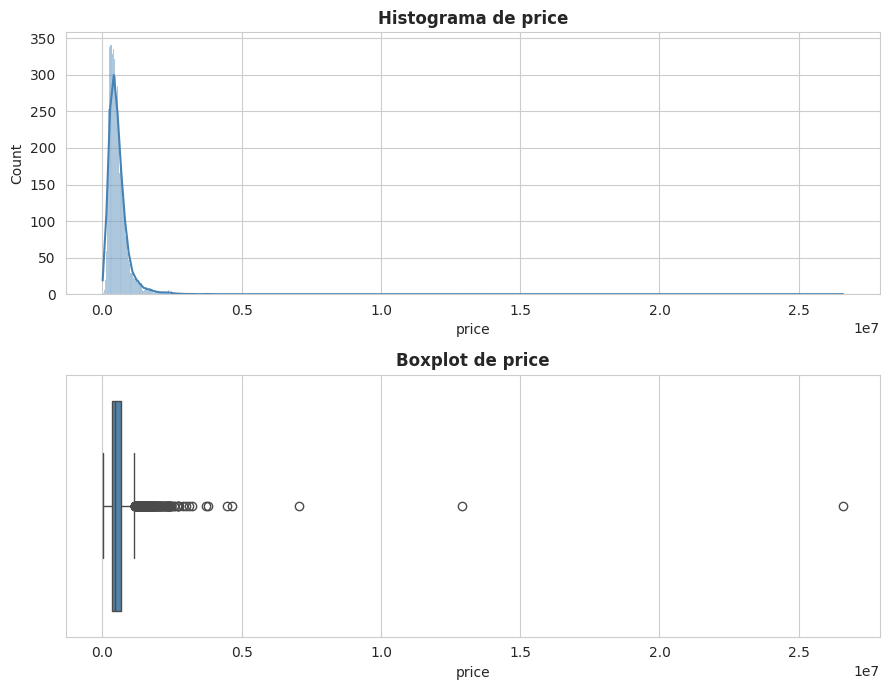


ANÁLISIS DE: BEDROOMS


,count,mean,std,min,25%,50%,75%,max
bedrooms,4551.0,3.394639,0.904595,0.0,3.0,3.0,4.0,9.0


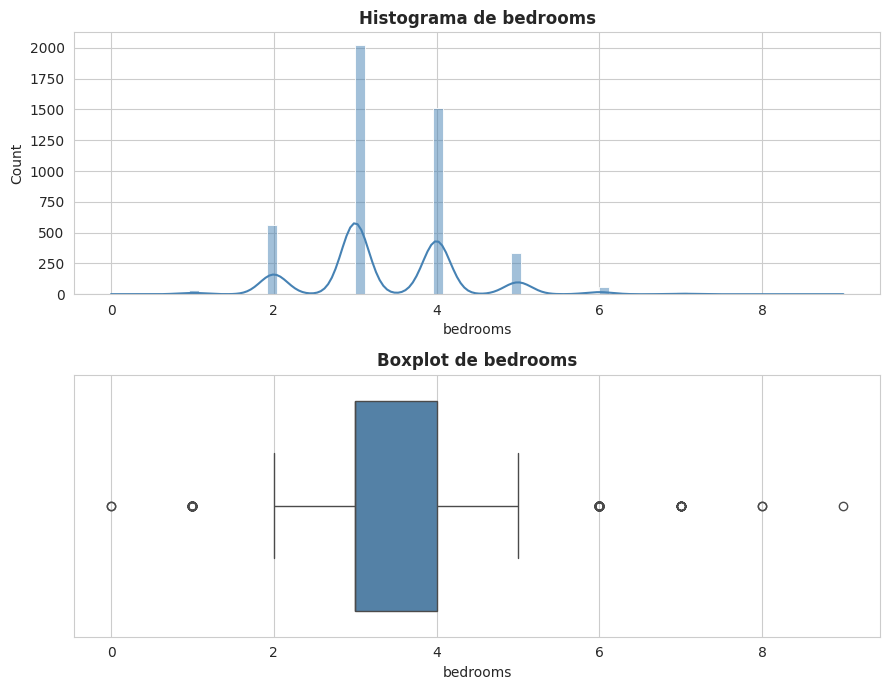


ANÁLISIS DE: BATHROOMS


,count,mean,std,min,25%,50%,75%,max
bathrooms,4551.0,2.155021,0.776351,0.0,1.75,2.25,2.5,8.0


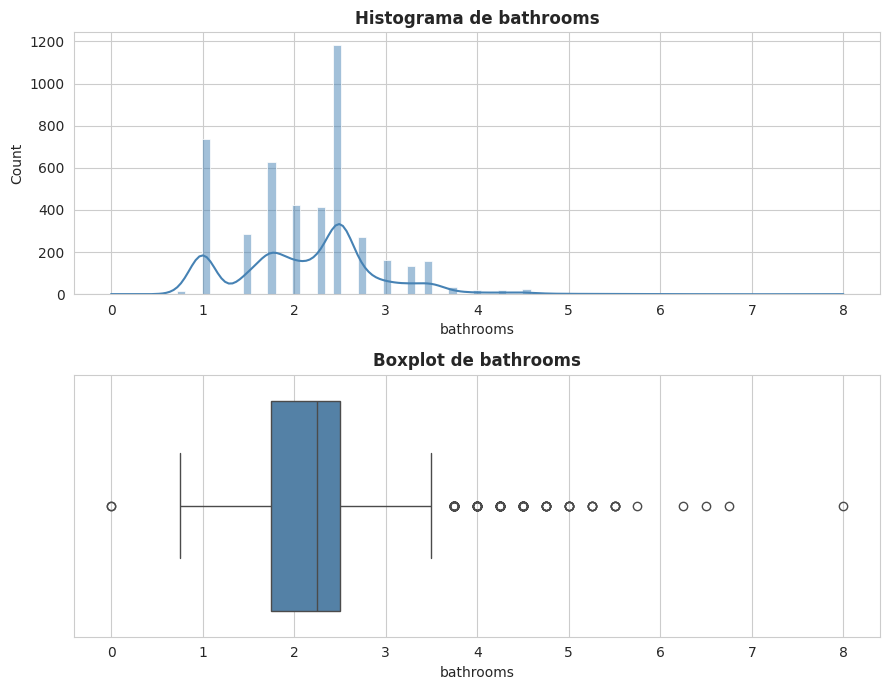


ANÁLISIS DE: SQFT_LIVING


,count,mean,std,min,25%,50%,75%,max
sqft_living,4551.0,2132.372226,955.949708,370.0,1460.0,1970.0,2610.0,13540.0


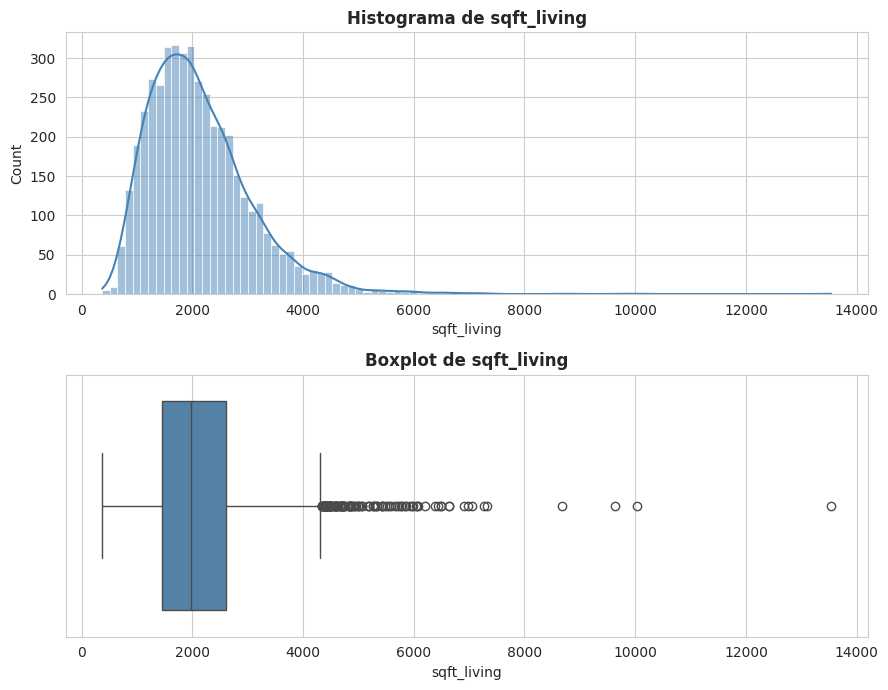


ANÁLISIS DE: SQFT_LOT


,count,mean,std,min,25%,50%,75%,max
sqft_lot,4551.0,14835.280598,35964.077825,638.0,5000.0,7680.0,10978.0,1074218.0


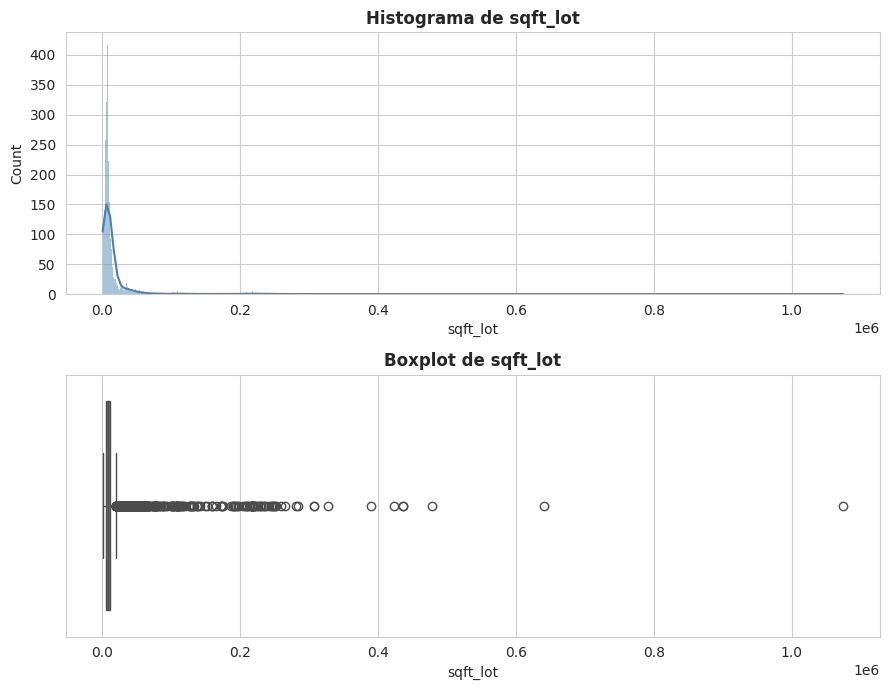


ANÁLISIS DE: SQFT_ABOVE


,count,mean,std,min,25%,50%,75%,max
sqft_above,4551.0,1822.22171,854.452888,370.0,1190.0,1590.0,2300.0,9410.0


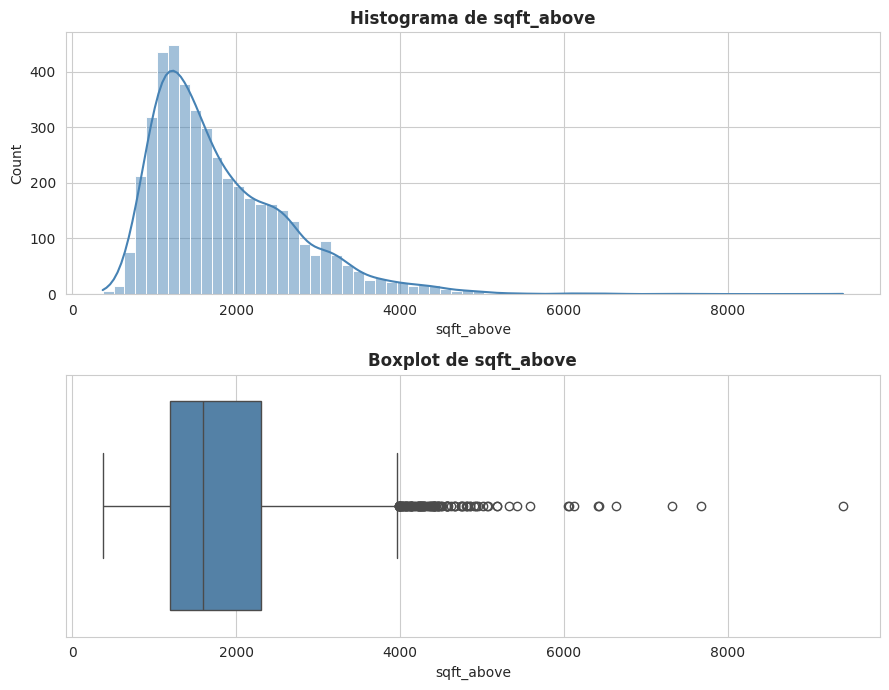


ANÁLISIS DE: SQFT_BASEMENT


,count,mean,std,min,25%,50%,75%,max
sqft_basement,4551.0,310.150516,461.987629,0.0,0.0,0.0,600.0,4820.0


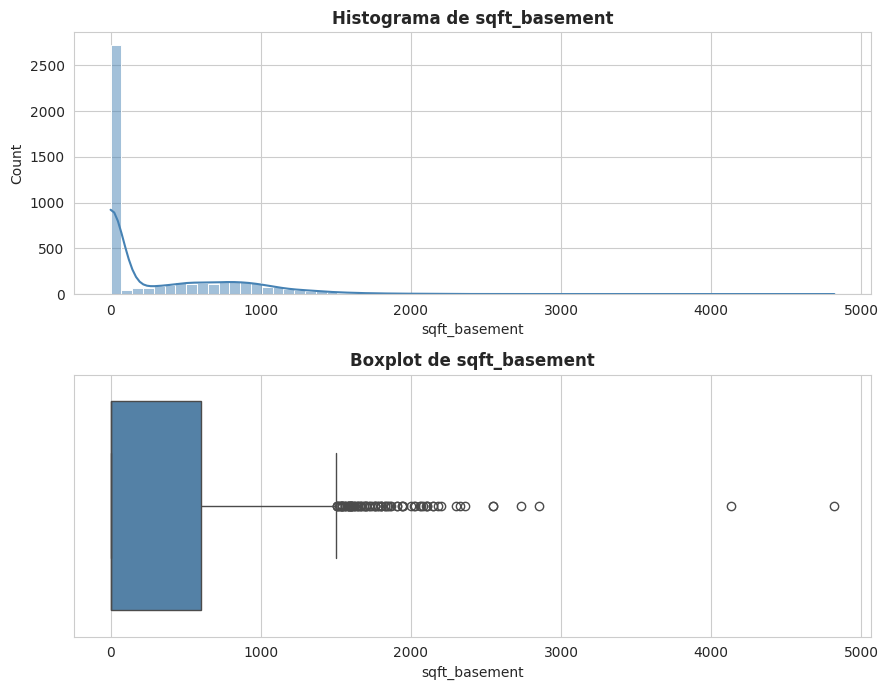


ANÁLISIS DE: YR_BUILT


,count,mean,std,min,25%,50%,75%,max
yr_built,4551.0,1970.795649,29.760073,1900.0,1951.0,1976.0,1997.0,2014.0


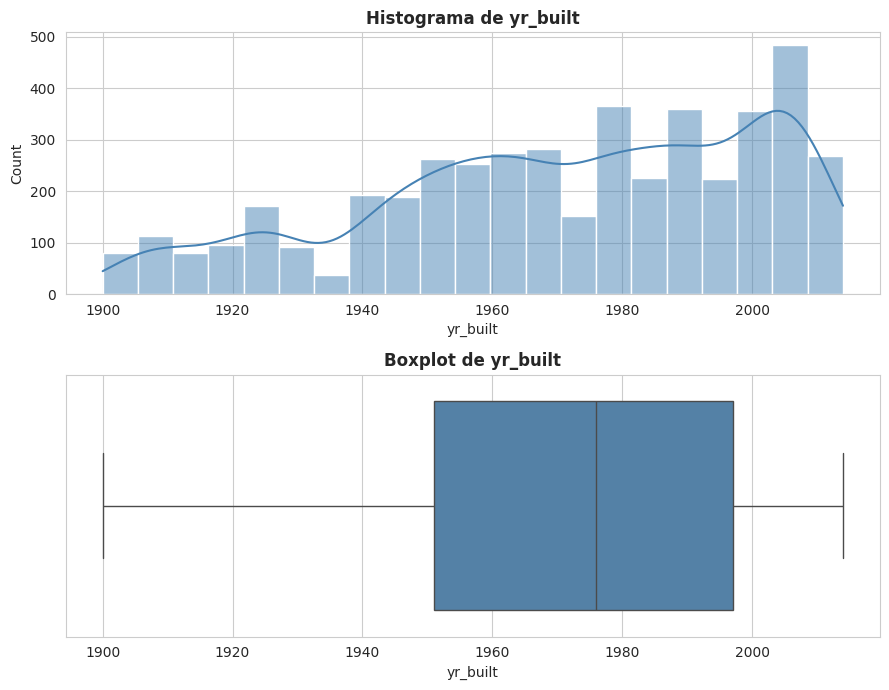


ANÁLISIS DE: YR_RENOVATED


,count,mean,std,min,25%,50%,75%,max
yr_renovated,4551.0,808.564052,979.421487,0.0,0.0,0.0,1999.0,2014.0


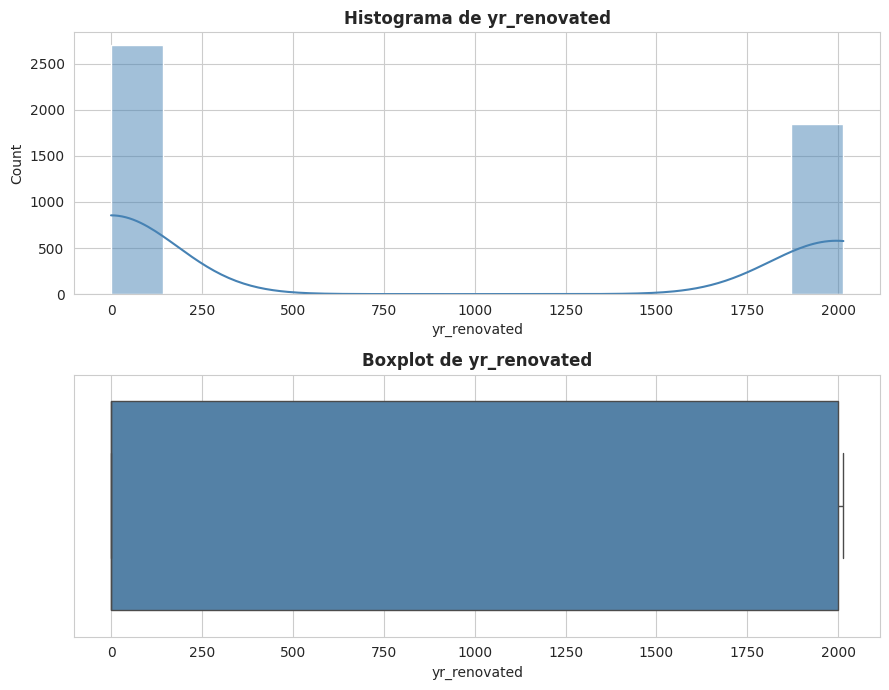


ANÁLISIS DE: PRICE_PER_SQFT


,count,mean,std,min,25%,50%,75%,max
price_per_sqft,4551.0,268.738862,358.351196,10.0,182.89,245.42,315.735,22533.9


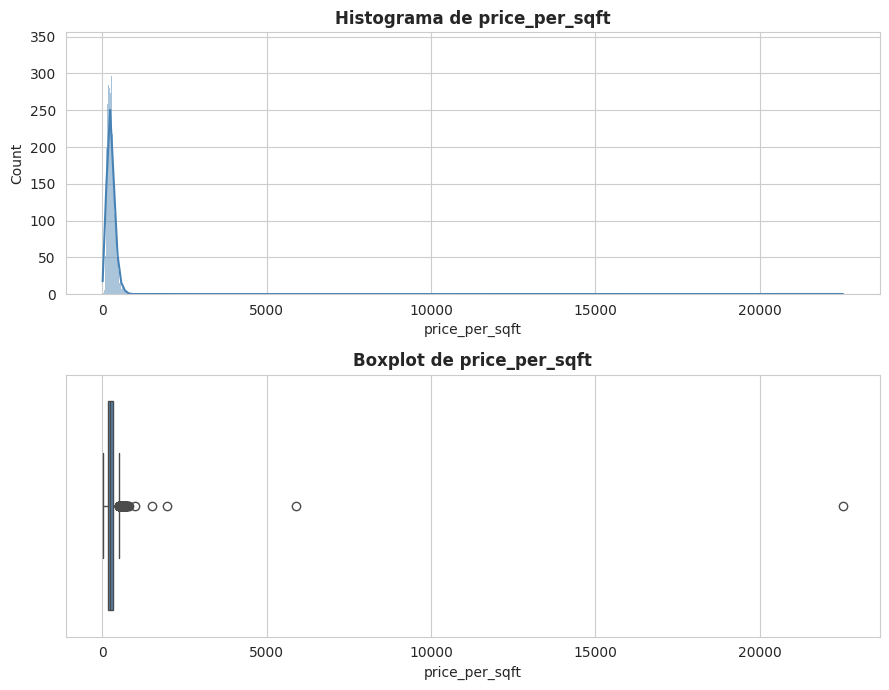

In [10]:
for col in columns_numerical:
    print(f"\n{'='*70}")
    print(f"ANÁLISIS DE: {col.upper()}")
    print(f"{'='*70}")

    stats = data[col].describe().to_frame().T
    display(stats)

    fig, axes = plt.subplots(2, 1, figsize=(9, 7))

    sns.histplot(data=data, x=col, ax=axes[0], color='steelblue', kde=True)
    axes[0].set_title(f'Histograma de {col}', fontsize=12, fontweight='bold')

    sns.boxplot(data=data, x=col, ax=axes[1], color='steelblue')
    axes[1].set_title(f'Boxplot de {col}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()


## Temporal

Fecha mínima: 2014-05-02 00:00:00
Fecha máxima: 2014-07-10 00:00:00


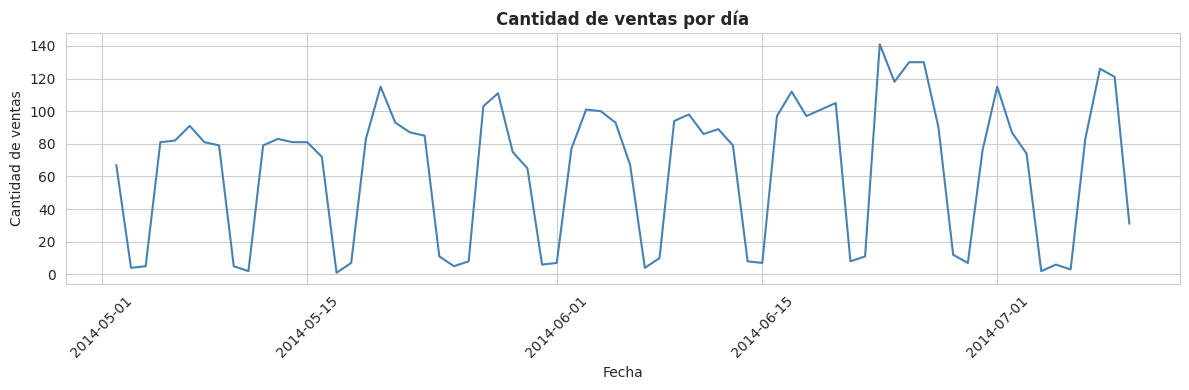

In [11]:
print("Fecha mínima:", data['date'].min())
print("Fecha máxima:", data['date'].max())

ventas_por_dia = data['date'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
sns.lineplot(x=ventas_por_dia.index, y=ventas_por_dia.values, color='steelblue')
plt.title('Cantidad de ventas por día', fontsize=12, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de ventas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Análisis bivariante\n\n## Numérico - Numérico

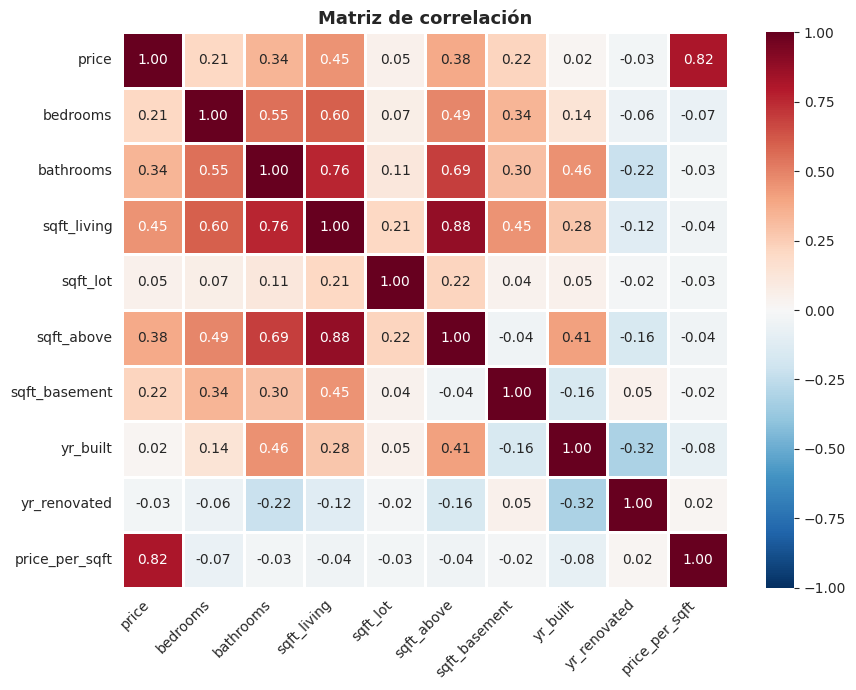

In [12]:
corr_matrix = data[columns_numerical].corr().round(2)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=1, linecolor='white'
)
plt.title('Matriz de correlación', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


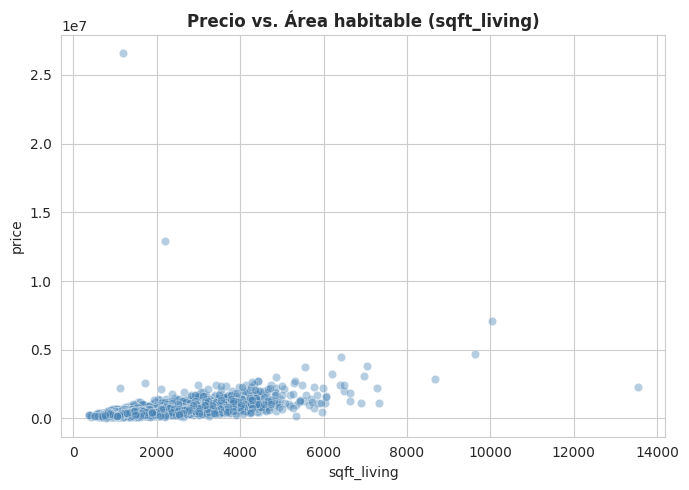

In [13]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='sqft_living', y='price', alpha=0.4, color='steelblue')
plt.title('Precio vs. Área habitable (sqft_living)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Categórico - Numérico

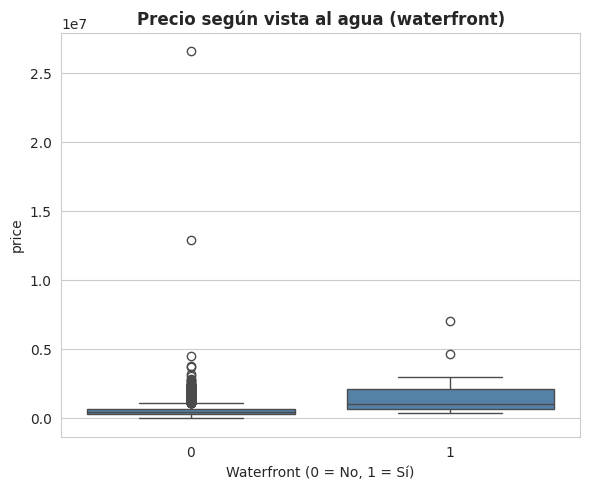

In [14]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=data, x='waterfront', y='price', color='steelblue')
plt.title('Precio según vista al agua (waterfront)', fontsize=12, fontweight='bold')
plt.xlabel('Waterfront (0 = No, 1 = Sí)')
plt.tight_layout()
plt.show()


/sessions/gallant-wizardly-lovelace/tmp/ipykernel_8/1216332272.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order=subset_top_cities.groupby('city')['price'].median().sort_values(ascending=False).index)


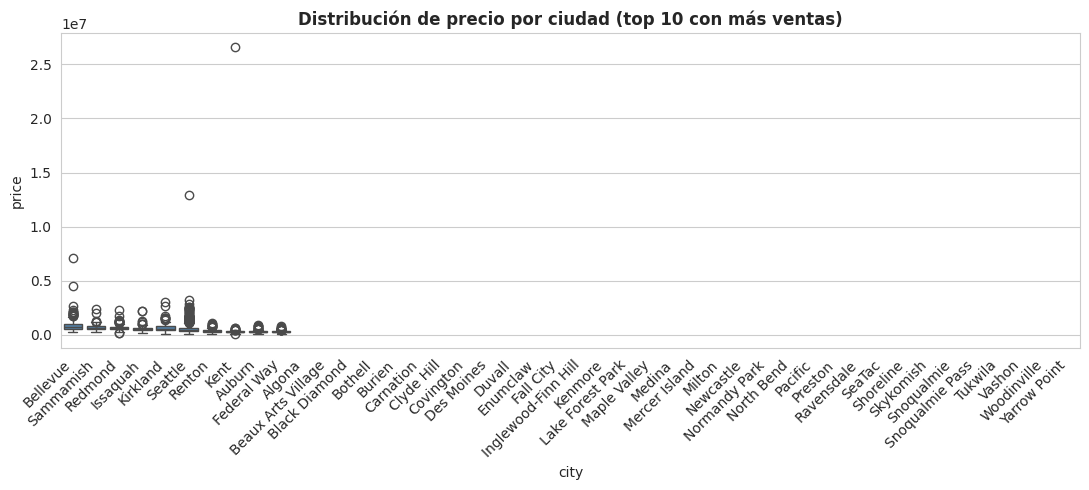

In [15]:
top_cities = data['city'].value_counts().head(10).index
subset_top_cities = data[data['city'].isin(top_cities)]

plt.figure(figsize=(11, 5))
sns.boxplot(data=subset_top_cities, x='city', y='price', color='steelblue',
            order=subset_top_cities.groupby('city')['price'].median().sort_values(ascending=False).index)
plt.title('Distribución de precio por ciudad (top 10 con más ventas)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


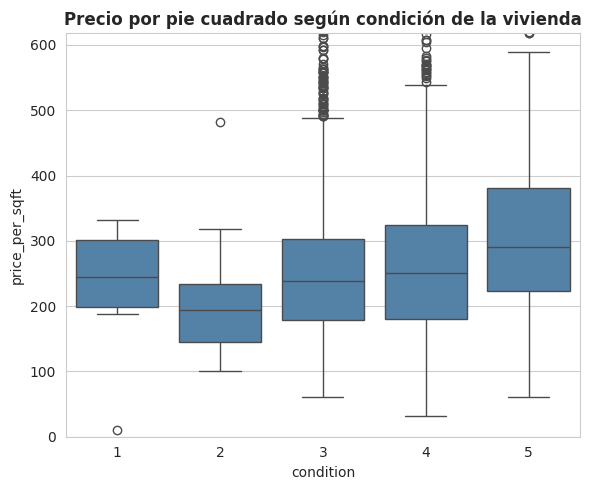

In [16]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=data, x='condition', y='price_per_sqft', color='steelblue')
plt.ylim(0, data['price_per_sqft'].quantile(0.99))
plt.title('Precio por pie cuadrado según condición de la vivienda', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Temporal - Numérico

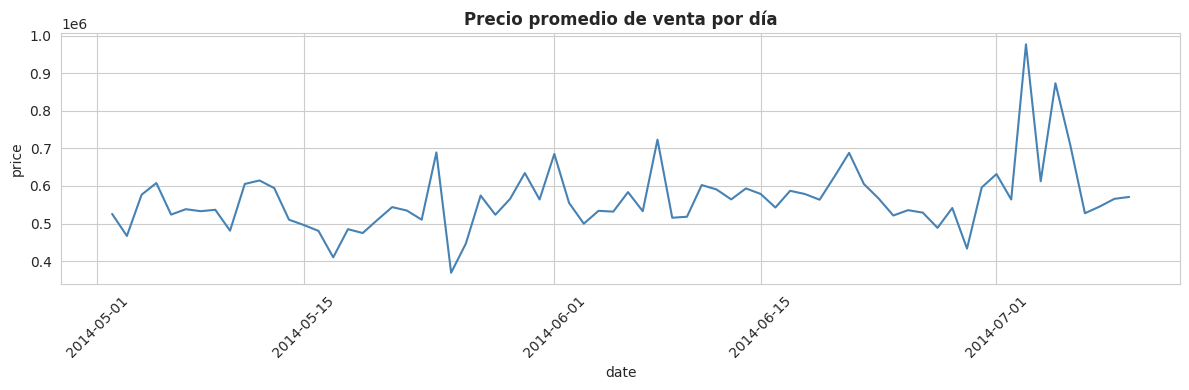

In [17]:
precio_promedio_diario = data.groupby('date')['price'].mean().reset_index()

plt.figure(figsize=(12, 4))
sns.lineplot(data=precio_promedio_diario, x='date', y='price', color='steelblue')
plt.title('Precio promedio de venta por día', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Cinco preguntas de análisis

1. ¿Qué ciudades tienen el precio promedio de vivienda más alto?
2. ¿Qué tan fuerte es la relación entre el tamaño de la vivienda (sqft_living) y el precio de venta?
3. ¿Las casas con vista al agua (waterfront) se venden a un precio significativamente mayor?
4. ¿El año de construcción influye en el precio de la vivienda?
5. ¿La condición de la vivienda influye en el precio por pie cuadrado?

## Pregunta 1: ¿Qué ciudades tienen el precio promedio de vivienda más alto?

/sessions/gallant-wizardly-lovelace/tmp/ipykernel_8/626018774.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('city')['price']


,precio_promedio,cantidad_ventas
city,,
Mercer Island,1.178638e+06,82
Bellevue,8.622551e+05,281
Sammamish,7.029858e+05,171
Redmond,6.676495e+05,235
Newcastle,6.660467e+05,33
Kirkland,6.515836e+05,187
Woodinville,6.149121e+05,114
Issaquah,5.993689e+05,186
Seattle,5.842949e+05,1561


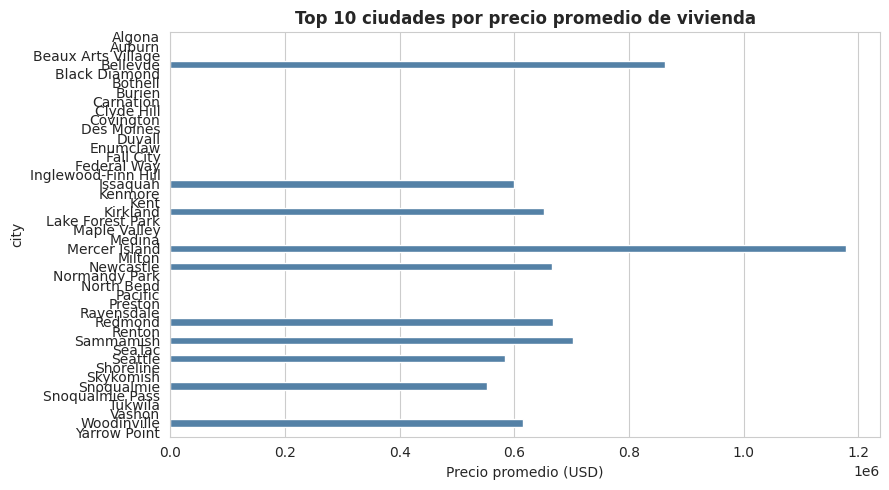

In [18]:
precio_promedio_ciudad = (
    data.groupby('city')['price']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'precio_promedio', 'count': 'cantidad_ventas'})
)

# Filtramos ciudades con al menos 20 ventas para evitar promedios poco representativos
precio_promedio_ciudad = precio_promedio_ciudad[precio_promedio_ciudad['cantidad_ventas'] >= 20]
precio_promedio_ciudad = precio_promedio_ciudad.sort_values('precio_promedio', ascending=False)

top10_ciudades = precio_promedio_ciudad.head(10)
display(top10_ciudades)

plt.figure(figsize=(9, 5))
sns.barplot(x=top10_ciudades['precio_promedio'], y=top10_ciudades.index, color='steelblue')
plt.title('Top 10 ciudades por precio promedio de vivienda', fontsize=12, fontweight='bold')
plt.xlabel('Precio promedio (USD)')
plt.tight_layout()
plt.show()


**Conclusión:** Las ciudades con el precio promedio más alto corresponden a zonas reconocidas como de mayor poder adquisitivo dentro del área metropolitana de Seattle. Esto confirma que la ubicación es un factor determinante en el precio de una vivienda.

## Pregunta 2: ¿Qué tan fuerte es la relación entre el tamaño de la vivienda y el precio?

Correlación entre sqft_living y price: 0.445


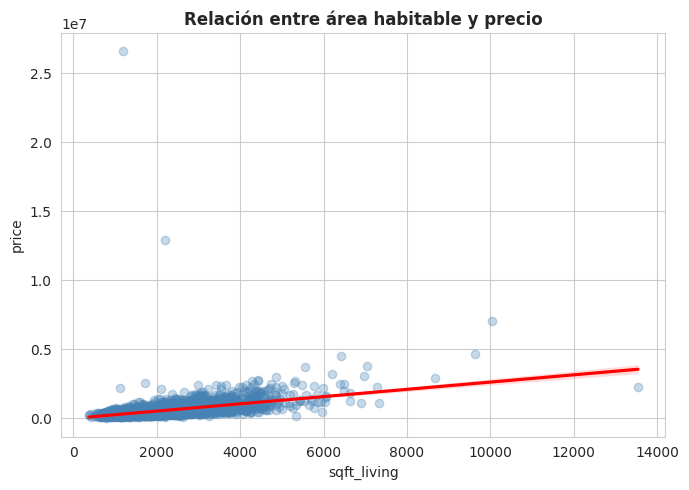

In [19]:
correlacion = data['sqft_living'].corr(data['price'])
print(f"Correlación entre sqft_living y price: {correlacion:.3f}")

plt.figure(figsize=(7, 5))
sns.regplot(data=data, x='sqft_living', y='price', scatter_kws={'alpha': 0.3, 'color': 'steelblue'},
            line_kws={'color': 'red'})
plt.title('Relación entre área habitable y precio', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Conclusión:** Existe una correlación positiva y moderada-alta entre el área habitable (`sqft_living`) y el precio de venta: a mayor tamaño de la vivienda, mayor tiende a ser su precio, aunque la dispersión indica que otros factores (ubicación, condición, año de construcción) también influyen.

## Pregunta 3: ¿Las casas con vista al agua se venden a un precio significativamente mayor?

In [20]:
comparacion_waterfront = data.groupby('waterfront')['price'].agg(['mean', 'median', 'count'])
display(comparacion_waterfront)

diferencia_pct = (comparacion_waterfront.loc[1, 'mean'] / comparacion_waterfront.loc[0, 'mean'] - 1) * 100
print(f"Las casas con vista al agua cuestan en promedio un {diferencia_pct:.1f}% más que las que no la tienen.")


/sessions/gallant-wizardly-lovelace/tmp/ipykernel_8/4164140845.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comparacion_waterfront = data.groupby('waterfront')['price'].agg(['mean', 'median', 'count'])


,mean,median,count
waterfront,,,
0,5.510122e+05,464000.0,4521
1,1.596783e+06,1072500.0,30


Las casas con vista al agua cuestan en promedio un 189.8% más que las que no la tienen.


**Conclusión:** Las viviendas con vista al agua (`waterfront = 1`) tienen un precio promedio considerablemente más alto que las que no la tienen, aunque representan una proporción muy pequeña del total de ventas, por lo que ese promedio es más sensible a valores atípicos.

## Pregunta 4: ¿El año de construcción influye en el precio de la vivienda?

decada_construccion
1900    654369.996855
1910    608684.436982
1920    607486.565837
1930    693472.747611
1940    448473.597696
1950    508277.984108
1960    454735.773315
1970    526427.444338
1980    544711.304280
1990    632156.193443
2000    617964.006288
2010    587300.435688
Name: price, dtype: float64

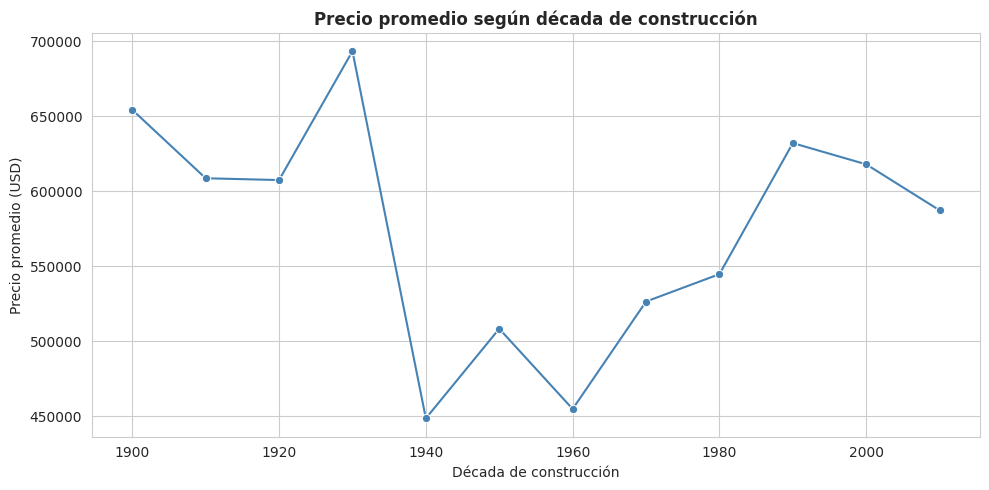

In [21]:
data['decada_construccion'] = (data['yr_built'] // 10) * 10

precio_por_decada = data.groupby('decada_construccion')['price'].mean()
display(precio_por_decada)

plt.figure(figsize=(10, 5))
sns.lineplot(x=precio_por_decada.index, y=precio_por_decada.values, marker='o', color='steelblue')
plt.title('Precio promedio según década de construcción', fontsize=12, fontweight='bold')
plt.xlabel('Década de construcción')
plt.ylabel('Precio promedio (USD)')
plt.tight_layout()
plt.show()


**Conclusión:** No se observa una tendencia estrictamente lineal entre año de construcción y precio: las viviendas más nuevas tienden a ser algo más costosas, pero también hay casas antiguas con precios altos, probablemente por ubicación o remodelaciones (`yr_renovated`).

## Pregunta 5: ¿La condición de la vivienda influye en el precio por pie cuadrado?

/sessions/gallant-wizardly-lovelace/tmp/ipykernel_8/302989152.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  precio_m2_por_condicion = data.groupby('condition')['price_per_sqft'].median()


condition
1    245.340
2    194.120
3    238.310
4    251.425
5    289.870
Name: price_per_sqft, dtype: float64

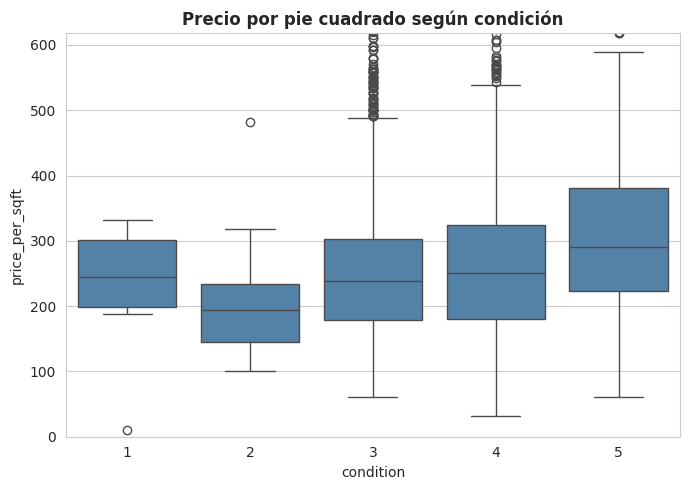

In [22]:
precio_m2_por_condicion = data.groupby('condition')['price_per_sqft'].median()
display(precio_m2_por_condicion)

plt.figure(figsize=(7, 5))
sns.boxplot(data=data, x='condition', y='price_per_sqft', color='steelblue')
plt.ylim(0, data['price_per_sqft'].quantile(0.99))
plt.title('Precio por pie cuadrado según condición', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Conclusión:** Se observa una relación positiva entre la condición reportada de la vivienda y el precio por pie cuadrado: las viviendas en mejor condición tienden a venderse a un precio por pie cuadrado más alto, aunque la diferencia entre niveles intermedios de condición no es tan marcada como entre los extremos.